# SciGraphAgent Benchmark — Notebook 05
## Visualising Results: Five Publication-Quality Figures

---

**Notebook series:**
- Notebook 00 — Setup and foundations ✓
- Notebook 01 — Loading benchmark datasets ✓
- Notebook 02 — Building retrieval systems ✓
- Notebook 03 — Running experiments ✓
- Notebook 04 — Computing metrics ✓
- **Notebook 05 — Visualising results ← you are here**

---

## What this notebook teaches

**Part A — Practical constraints:**
- Why step05 costs $0 — zero API calls, pure computation
- Why figures matter in research — what a reviewer sees first
- Matplotlib vs Plotly vs Seaborn — which to use and when
- Why 300 dpi — the exact resolution required for paper submission
- What colour-blind safe palettes are and why they are required
- The non-interactive backend — what `Agg` means and why we use it
- Separation of display and save — why both matter

**Part B — Visualisation concepts:**
- What grouped bar charts communicate — when to use them
- What paired bar charts show — treatment vs control
- What horizontal gauge charts are — threshold comparisons
- What scatter plots position — two-axis comparisons
- What heatmaps reveal — patterns across two dimensions
- How to annotate figures honestly — notes, caveats, limitations
- How to read each of the five figures we generate

**Part C — Running step05:**
- Generate all five figures
- Interpret each figure output honestly
- Apply the two cosmetic fixes identified from visual inspection
- Pre-commit verification and commit

---

## How to use this notebook

Each section follows the same pattern:
1. **Theory** — the concept from scratch
2. **Code** — implementation with comments
3. **Observe** — what the output means
4. **📌 Retain** — general principle + formula + project application + future generalisation

---
## Section 1 — Environment Setup

In [1]:
from dotenv import load_dotenv
import os, json
from pathlib import Path

cwd = Path(os.getcwd())
dotenv_path = cwd.parent / ".env" if (cwd.parent / ".env").exists() else cwd / ".env"
load_dotenv(dotenv_path)

print("Working directory:", cwd)
print("API calls needed : ZERO (step05 generates figures only)")
print("Cost             : $0.00")
print()

# Check prerequisites
required = [
    Path("results") / "metrics_hotpotqa_3.json",
    Path("results") / "raw_results_hotpotqa_3.json",
    Path("step05_visualise.py"),
]
all_ok = True
for p in required:
    exists = p.exists()
    size   = f"{p.stat().st_size // 1024} KB" if exists else ""
    print(f"  {'✓' if exists else '✗'} {p}  {size}")
    if not exists: all_ok = False

# Check figures directory
figs_dir = Path("results") / "figures"
if figs_dir.exists():
    pngs = list(figs_dir.glob("*.png"))
    print(f"\n  Figures already generated: {len(pngs)}")
    for p in sorted(pngs):
        print(f"    {p.name}  ({p.stat().st_size // 1024} KB)")

print()
print("✓ Ready to visualise" if all_ok else "✗ Run step04 first")

Working directory: /run/media/bala/HDD/Projects/scigraphagent-benchmark
API calls needed : ZERO (step05 generates figures only)
Cost             : $0.00

  ✓ results/metrics_hotpotqa_3.json  2 KB
  ✓ results/raw_results_hotpotqa_3.json  18 KB
  ✓ step05_visualise.py  24 KB

  Figures already generated: 5
    fig1_ablation_hotpotqa_3.png  (220 KB)
    fig2_retry_gate_hotpotqa_3.png  (180 KB)
    fig3_cicd_gate_hotpotqa_3.png  (144 KB)
    fig4_literature_hotpotqa_3.png  (255 KB)
    fig5_heatmap_hotpotqa_3.png  (210 KB)

✓ Ready to visualise


---
# PART A — Practical Constraints

## Section 2 — Why Figures Matter in Research

### What a reviewer sees first

When a paper reviewer opens your submission, their eyes go to the figures before the text. A well-designed figure communicates the key result in under 10 seconds. A poorly designed figure forces the reviewer to read three paragraphs to understand what they are looking at — and reviewers under time pressure may not do that.

**The figure is not decoration. It is the argument.**

Fig 1 (ablation bar chart) should make the recall lift from B to D immediately visible. Fig 2 (retry gate) should make the faithfulness improvement jump out. If the viewer has to squint or count numbers to see the difference, the figure is failing its job.

### The five figures and what argument each makes

| Figure | Type | Argument it makes |
|---|---|---|
| Fig 1 | Grouped bar chart | Graph retrieval adds recall beyond vector-only |
| Fig 2 | Paired bar chart | Retry gate improves faithfulness over single pass |
| Fig 3 | Horizontal gauge | CI/CD gate correctly distinguishes V1 from V2 |
| Fig 4 | Scatter plot | We are the only system in the GPU-free + gate region |
| Fig 5 | Heatmap | Condition A (no retrieval) fails uniformly; B/C/D succeed |

### Why step05 costs $0

Figures are generated entirely from the JSON file written by step04. No model inference, no API calls, no network. Step05 runs in under 5 seconds on any machine.

This means you can:
- Change a colour and regenerate in 5 seconds
- Try a different figure type and regenerate
- Fix a label and regenerate

Without spending a single token. This is the payoff of the separation-of-concerns design established in step04.

---
## Section 3 — Matplotlib vs Plotly vs Seaborn: Which to Use and When

### The three main Python visualisation libraries

**Matplotlib** — the foundation. Every other library builds on it. Produces static PNG/PDF/SVG files. Total control over every pixel. Verbose but powerful.

**Seaborn** — built on matplotlib. Prettier defaults, designed for statistical plots (violin, kde, regression). Less control than raw matplotlib. Not suitable for custom figure layouts.

**Plotly** — interactive HTML figures. Hover tooltips, zoom, pan. Excellent for dashboards and exploration. Cannot produce print-quality static figures without extra dependencies. Step06 uses Plotly for the Streamlit dashboard.

### Why we chose matplotlib for step05

| Requirement | Matplotlib | Seaborn | Plotly |
|---|---|---|---|
| 300 dpi PNG for paper | ✓ | ✓ | ✗ (needs kaleido) |
| Custom layouts (3 panels) | ✓ | ✗ | ~ |
| Colour-blind palette control | ✓ | ~ | ✓ |
| No extra dependencies | ✓ | ✓ | ✗ |
| Annotation control | ✓ | ✗ | ~ |
| Works headless (no display) | ✓ (Agg) | ✓ | ✓ |

Matplotlib wins for paper figures. Plotly wins for interactive exploration. They serve different purposes — we use both in this project.

### What `matplotlib.use('Agg')` means

Matplotlib normally tries to open a display window to show figures interactively. On a server, a headless machine, or when running from a terminal script, there is no display — and matplotlib will crash.

The `Agg` backend tells matplotlib: "Do not try to open a window. Render the figure to a memory buffer (AGG = Anti-Grain Geometry renderer) and only write to disk when I call `savefig()`." 

This is why step05 works on any machine — remote servers, CI/CD pipelines, Docker containers — without needing a display.

### Why 300 dpi?

DPI = dots per inch. It determines how sharp a figure looks when printed.

- **72 dpi:** Screen resolution. Looks fine on screen, blurry when printed.
- **150 dpi:** Acceptable for reports. Not for journals.
- **300 dpi:** Standard for academic journals and conference proceedings.
- **600 dpi:** Required by some journals for line art (diagrams).

IEEE, ACM, AAAI, NeurIPS, ICML — all specify minimum 300 dpi for figures. We use 300 dpi so the figures are submission-ready.

In [2]:
# Demonstrate the practical difference between dpi settings
# and the Agg backend

import matplotlib
matplotlib.use("Agg")   # non-interactive — must be called before pyplot import
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Show what backend is active
print(f"Active matplotlib backend: {matplotlib.get_backend()}")
print(f"  Agg = Anti-Grain Geometry renderer")
print(f"  No display window opened — renders to memory buffer only")
print()

# Demonstrate dpi effect on file size and sharpness
demo_dir = Path("results") / "figures"
demo_dir.mkdir(parents=True, exist_ok=True)

print("DPI comparison (same figure, different resolutions):")
print(f"{'DPI':>5} {'File size':>12} {'Dimensions (px)':>18} {'Use case'}")
print("-" * 60)

for dpi in [72, 150, 300]:
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.linspace(0, 10, 100)
    ax.plot(x, np.sin(x), linewidth=2)
    ax.set_title(f"Example at {dpi} dpi")
    path = demo_dir / f"_demo_{dpi}dpi.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)

    size_kb = path.stat().st_size // 1024
    # Estimate pixel dimensions
    px_w = int(6 * dpi)
    px_h = int(4 * dpi)
    use  = {72: "screen only", 150: "reports", 300: "papers/journals"}[dpi]
    print(f"{dpi:>5} {size_kb:>10} KB {px_w}×{px_h:>4} px{' ':>4} {use}")
    path.unlink()   # clean up demo files

print()
print("Our step05 uses 300 dpi — submission-ready for IEEE, ACM, NeurIPS, ICML.")
print()

# Show savefig parameters we use
print("Our savefig call:")
print('  fig.savefig(path,')
print('              dpi=300,')
print('              bbox_inches="tight",   # no clipping of labels')
print('              facecolor="white",     # white background for print')
print('              edgecolor="none")      # no border around figure')

Active matplotlib backend: Agg
  Agg = Anti-Grain Geometry renderer
  No display window opened — renders to memory buffer only

DPI comparison (same figure, different resolutions):
  DPI    File size    Dimensions (px) Use case
------------------------------------------------------------
   72         17 KB 432× 288 px     screen only
  150         40 KB 900× 600 px     reports
  300         89 KB 1800×1200 px     papers/journals

Our step05 uses 300 dpi — submission-ready for IEEE, ACM, NeurIPS, ICML.

Our savefig call:
  fig.savefig(path,
              dpi=300,
              bbox_inches="tight",   # no clipping of labels
              facecolor="white",     # white background for print
              edgecolor="none")      # no border around figure


### 📌 Retain: Matplotlib for publication figures

**General principle:** Use matplotlib for static publication figures (papers, reports). Use Plotly for interactive exploration dashboards. Use seaborn for quick statistical plots during EDA.

**Three settings always needed for paper figures:**
```python
matplotlib.use("Agg")           # 1. headless backend
fig.savefig(path, dpi=300,      # 2. 300 dpi for journals
            bbox_inches="tight") # 3. no label clipping
```

**Generalise:** Any time you generate figures for a paper, report, slide deck, or printed material — use 300 dpi minimum. 72 dpi looks fine on screen but blurry in print. Most journals will desk-reject papers with low-resolution figures.

---
## Section 4 — Colour-Blind Safe Palettes

### Why this matters

Approximately 8% of men and 0.5% of women have some form of colour vision deficiency. The most common form is red-green colour blindness — these people cannot distinguish red from green.

If your figure uses red and green to show "bad" and "good", approximately 1 in 12 male readers cannot read it. Many journals (Nature, Science, PLOS ONE) now explicitly require colour-blind accessible figures.

### The Wong (2011) palette — what we use

Bang Wong's 8-colour palette (published in Nature Methods, 2011) is specifically designed to be distinguishable by people with all common forms of colour vision deficiency.

```python
PALETTE = {
    "black":  "#000000",
    "orange": "#E69F00",
    "sky":    "#56B4E9",
    "green":  "#009E73",
    "yellow": "#F0E442",
    "blue":   "#0072B2",
    "red":    "#D55E00",
    "pink":   "#CC79A7",
}
```

### What makes a palette colour-blind safe?

Colour-blind people distinguish colours primarily by **hue** (which part of the spectrum) and **luminance** (light vs dark). The Wong palette:
- Uses colours spread across the full hue spectrum
- Varies luminance systematically so colours differ in brightness even if the hue looks similar
- Avoids the red-green boundary that most colour-blind people cannot cross

### How we assign colours to conditions

Condition colours are fixed across all five figures:
- **A (no retrieval):** black — associated with absence/baseline
- **B (vector only):** sky blue — associated with standard/known
- **C (graph only):** orange — associated with alternative
- **D (hybrid):** dark blue — associated with our proposed system

In [3]:
# Demonstrate the Wong palette and show why it is colour-blind safe

PALETTE = {
    "black":  "#000000",
    "orange": "#E69F00",
    "sky":    "#56B4E9",
    "green":  "#009E73",
    "yellow": "#F0E442",
    "blue":   "#0072B2",
    "red":    "#D55E00",
    "pink":   "#CC79A7",
}

COND_COLOURS = {
    "A": PALETTE["black"],
    "B": PALETTE["sky"],
    "C": PALETTE["orange"],
    "D": PALETTE["blue"],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Left panel: Wong palette swatches
ax = axes[0]
for i, (name, hex_col) in enumerate(PALETTE.items()):
    ax.barh(i, 1, color=hex_col, height=0.7, edgecolor="gray", linewidth=0.3)
    ax.text(0.05, i, f"{name}: {hex_col}",
            va="center", fontsize=10, color="white" if name in ["black","blue"] else "black",
            fontweight="bold")
ax.set_xlim(0, 1.2)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Wong (2011) Colour-Blind Safe Palette", fontweight="bold")

# Right panel: condition colour assignment
ax2 = axes[1]
cond_labels = [
    ("A", "No retrieval",      "Absence/baseline"),
    ("B", "Vector only",       "Standard RAG"),
    ("C", "Graph only",        "Graph RAG"),
    ("D", "Hybrid (proposed)", "Our system"),
]
for i, (letter, name, role) in enumerate(cond_labels):
    col = COND_COLOURS[letter]
    ax2.barh(i, 1, color=col, height=0.7, edgecolor="gray", linewidth=0.3)
    ax2.text(0.05, i, f"{letter}: {name} — {role}",
             va="center", fontsize=10,
             color="white" if letter in ["A","D"] else "black",
             fontweight="bold")
ax2.set_xlim(0, 1.5)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_title("Condition Colour Assignment\n(consistent across all 5 figures)",
              fontweight="bold")

plt.tight_layout()
plt.savefig("results/figures/_palette_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Palette demo saved.")
print()
print("Key rule: same condition = same colour across ALL figures.")
print("Condition D is always dark blue. A reviewer who learns this")
print("from Fig 1 immediately recognises it in Figs 2-5.")

Palette demo saved.

Key rule: same condition = same colour across ALL figures.
Condition D is always dark blue. A reviewer who learns this
from Fig 1 immediately recognises it in Figs 2-5.


/tmp/ipykernel_112622/3499980070.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 📌 Retain: Colour-blind safe design

**General principle:** Always use a colour-blind safe palette for any figure that will be published, presented, or printed. ~8% of male readers cannot distinguish red from green.

**The three rules:**
1. Use Wong (2011) or Okabe-Ito (2008) palette — both are validated
2. Vary luminance as well as hue — colours should differ in brightness
3. Never rely on colour alone to convey information — add labels, patterns, or shapes

**Consistency rule:** Once you assign a colour to a category (condition D = dark blue), keep it throughout the entire paper. A reader who memorises the colour scheme from Fig 1 should not need to re-learn it for Fig 5.

**Generalise:** This applies to any multi-figure document — ML papers, business reports, slide decks, dashboards. Consistent colour assignment + colour-blind safe palette is a professional standard, not an optional extra.

---
# PART B — Visualisation Concepts

## Section 5 — What Each Figure Type Communicates

### Fig 1: Grouped bar chart — comparing categories across metrics

**When to use:** You have multiple categories (conditions A/B/C/D) and multiple metrics (faithfulness, F1, recall) and want to compare all combinations simultaneously.

**What the viewer reads:** The height of each bar is the score. Within each panel, the viewer compares heights across conditions. The key comparison is: is D taller than B in the recall panel?

**Design decision — three separate panels instead of one:**
Putting all three metrics in one chart with 12 bars would be cluttered and hard to read. Three panels with 4 bars each is cleaner. The trade-off is that the viewer cannot directly compare F1 heights to recall heights — but that comparison is not meaningful (different scales of measurement).

### Fig 2: Paired bar chart — treatment vs control

**When to use:** You have exactly two conditions (no-gate vs with-gate) and want to show the difference on multiple metrics simultaneously.

**What the viewer reads:** The left bar is the control, the right is the treatment. Any height difference is the treatment effect. The Δ annotation makes the delta explicit.

**Why paired bars instead of a line chart:**
A line chart connecting no-gate to with-gate would imply a continuous variable between the two — but there is no intermediate state. Bars correctly imply discrete categories.

### Fig 3: Horizontal gauge — threshold comparison

**When to use:** You have a threshold that divides pass from fail, and you want to show whether each system crosses it.

**What the viewer reads:** Does the bar reach the threshold line? Simple binary judgment. Horizontal orientation works better than vertical here because the threshold is a vertical rule — the bar "crosses" it from left to right, which reads naturally.

### Fig 4: Scatter plot — two-axis positioning

**When to use:** You want to show where each system sits on two independent axes simultaneously. Systems that are good on both axes appear in the top-right corner.

**What the viewer reads:** We are in the top-left corner (high capability, low F1 at n=3). Published systems are in the bottom-right (high F1, lower capability). The argument is that no system occupies the top-right — that is our target position at n=1000.

**Honest design decision — hollow marker for our system:**
We use a hollow circle (unfilled) for our F1=0.000 at n=3 to signal "this is not our final result." A filled marker would imply a settled measurement. The hollow marker + label "(n=3, pending n=1000)" communicates the right level of uncertainty.

### Fig 5: Heatmap — patterns across two dimensions

**When to use:** You have a 2D matrix of values (conditions × questions) and want to show patterns — which conditions perform consistently, which questions are hard.

**What the viewer reads:** The colour of each cell is the faithfulness score. An all-red row means that condition failed on every question. An all-green column means that question was answered faithfully by every condition. The pattern at n=3 (A=red, B/C/D=green) shows clearly that retrieval helps.

In [4]:
# Mini demonstration of each figure type with simple synthetic data
# to understand the visual language before seeing the real figures

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Four figure types — visual language guide",
             fontsize=13, fontweight="bold")

# 1. Grouped bar chart
ax = axes[0]
cats   = ["A", "B", "C", "D"]
metric1 = [0.0, 0.6, 0.5, 0.8]
metric2 = [0.0, 0.3, 0.2, 0.4]
x = np.arange(4)
ax.bar(x - 0.2, metric1, 0.35, color=PALETTE["sky"],   label="Metric 1")
ax.bar(x + 0.2, metric2, 0.35, color=PALETTE["orange"], label="Metric 2")
ax.set_title("Grouped bar\n(compare categories)", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylim(0, 1); ax.legend(fontsize=7)
ax.set_ylabel("Score")

# 2. Paired bar chart
ax = axes[1]
metrics = ["Faith", "F1", "Relev"]
control = [0.6, 0.3, 0.4]
treatment = [0.8, 0.4, 0.6]
x2 = np.arange(3)
ax.bar(x2 - 0.2, control,   0.35, color=PALETTE["sky"],  label="Control")
ax.bar(x2 + 0.2, treatment, 0.35, color=PALETTE["blue"], label="Treatment")
for i, (c, t) in enumerate(zip(control, treatment)):
    ax.annotate(f"Δ{t-c:+.1f}", (i+0.2, t+0.02), ha="center", fontsize=7,
                color=PALETTE["green"])
ax.set_title("Paired bar\n(treatment effect)", fontsize=9)
ax.set_xticks(x2); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1); ax.legend(fontsize=7)

# 3. Horizontal gauge
ax = axes[2]
ax.barh([0, 1], [0.65, 0.90], height=0.5,
        color=[PALETTE["orange"], PALETTE["green"]])
ax.axvline(0.75, color="red", linewidth=2, linestyle="--")
ax.text(0.77, 1.3, "Threshold", fontsize=8, color="red")
ax.set_yticks([0,1]); ax.set_yticklabels(["System B", "System A"])
ax.set_xlim(0, 1.2)
ax.set_title("Horizontal gauge\n(threshold comparison)", fontsize=9)
ax.text(0.02, 0, "FAIL", color="white", va="center", fontsize=8, fontweight="bold")
ax.text(0.02, 1, "PASS", color="white", va="center", fontsize=8, fontweight="bold")

# 4. Heatmap
ax = axes[3]
data = np.array([[0.0, 0.0, 0.1],
                 [0.9, 1.0, 0.8],
                 [0.7, 1.0, 1.0]])
im = ax.imshow(data, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{data[i,j]:.1f}", ha="center", va="center",
                fontsize=9, fontweight="bold",
                color="white" if data[i,j] < 0.3 or data[i,j] > 0.7 else "black")
ax.set_yticks([0,1,2]); ax.set_yticklabels(["A","B","C"])
ax.set_xticks([0,1,2]); ax.set_xticklabels(["Q1","Q2","Q3"])
ax.set_title("Heatmap\n(2D patterns)", fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.6)

plt.tight_layout()
plt.savefig("results/figures/_figure_types_guide.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure types guide saved.")

Figure types guide saved.


/tmp/ipykernel_112622/3986859203.py:70: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 📌 Retain: Matching figure type to the comparison

**Decision rule:**
```
Comparing N categories across M metrics  → Grouped bar chart
Showing treatment effect (A vs B)        → Paired bar chart
Checking if a value crosses a threshold  → Horizontal gauge
Positioning on two independent axes      → Scatter plot
Showing patterns in a 2D matrix          → Heatmap
```

**The most common mistake:** Using a line chart to connect categorical data. Lines imply continuity — a line between "Condition A" and "Condition B" implies there is a meaningful intermediate state. Use bars for discrete categories.

**Generalise:** Every time you make a figure, ask: what comparison am I trying to show? Then pick the figure type that makes that comparison most immediately visible. The figure type is not aesthetic — it is logical.

---
## Section 6 — How to Annotate Figures Honestly

### The honesty principle in figures

A figure can mislead even when the underlying data is correct. Common misleading practices:

**Truncated y-axis:** Starting the y-axis at 0.7 instead of 0.0 makes a 0.02 difference look like a 50% improvement. Always start at 0 for bar charts.

**Missing uncertainty:** Showing only the mean without error bars hides variance. At n=3, the bars look precise — but with SE=±0.17, the true value could be anywhere from 0.50 to 1.00.

**Omitting failure cases:** If the CI/CD gate does not work at n=3, show that — with a clear label "unreliable at n=3." Do not hide the limitation.

### Three annotation elements we include in every figure

**1. Sample size in the title:** `(HOTPOTQA, n=3)` — the viewer immediately knows the reliability level.

**2. Italic note at the bottom:** `Note: n=3 smoke test. Target detectable at n≥50.` — this is the honest limitation, visible without reading the text.

**3. Hollow markers for unconfirmed results:** Our F1=0.000 at n=3 uses a hollow circle in Fig 4 — visually signals "pending confirmation" without hiding the data point.

### What the five figures say at n=3 vs n=50

| Figure | What n=3 shows | What n=50 will show |
|---|---|---|
| Fig 1 | Condition A=0, B/C/D=1 faithfulness | Recall lift D>B visible |
| Fig 2 | Faith=0.833 both conditions | Δfaith measurable |
| Fig 3 | V2 not blocked (judge variance) | V2 clearly below threshold |
| Fig 4 | Our system at F1=0.000 | Our system at F1=0.40+ |
| Fig 5 | Clear A=red, B/C/D=green | Per-question variation visible |

---
# PART C — Running Step05

## Section 7 — Generating All Five Figures

In [5]:
import importlib.util, time

spec = importlib.util.spec_from_file_location(
    "step05", Path("step05_visualise.py")
)
step05 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(step05)

print("Running step05.main(dataset='hotpotqa', n=3)")
print("API calls: ZERO | Cost: $0.00")
print()

t0 = time.perf_counter()
step05.main(dataset="hotpotqa", n=3)
elapsed = time.perf_counter() - t0

print(f"\nTotal time: {elapsed:.1f}s")
print("Compare to step03 (experiments): 5–8 minutes")
print("Visualisation is free to re-run — change anything and regenerate instantly.")

Running step05.main(dataset='hotpotqa', n=3)
API calls: ZERO | Cost: $0.00


  STEP 05: VISUALISE RESULTS
  Dataset : hotpotqa
  N       : 3
  Output  : /run/media/bala/HDD/Projects/scigraphagent-benchmark/results/figures
  API calls: 0 | Cost: $0.00

  Saving figures...
  Saved → results/figures/fig1_ablation_hotpotqa_3.png (220 KB)
  Saved → results/figures/fig2_retry_gate_hotpotqa_3.png (180 KB)
  Saved → results/figures/fig3_cicd_gate_hotpotqa_3.png (144 KB)
  Saved → results/figures/fig4_literature_hotpotqa_3.png (255 KB)
  Saved → results/figures/fig5_heatmap_hotpotqa_3.png (210 KB)

  ✓ 5/5 figures saved to results/figures
  ✓ Next: python step06_dashboard.py

Total time: 3.7s
Compare to step03 (experiments): 5–8 minutes
Visualisation is free to re-run — change anything and regenerate instantly.


---
## Section 8 — Interpreting Each Figure Honestly

Now that the figures are generated, here is what each one shows at n=3 and what it will show at n=50.

### Fig 1 — Four-Condition Ablation

**What you see at n=3:**
- Faithfulness panel: A=0.000, B=C=D=1.000 — retrieval clearly helps
- F1 panel: all zero — gold answers not in the n=3 indexed passages
- Recall panel: A=0.000, B=0.333, C=0.222, D=0.333 — vector and hybrid outperform graph-only
- Target dashed line at 0.48 (B+0.15=0.333+0.15) — neither C nor D reaches it

**Why this is expected:** At n=3, the three specific questions happen to favour vector retrieval. Graph traversal finds entity co-occurrences, but the specific bridging entities for these three questions are not strongly represented in the tiny graph built from 3 passages.

**What to expect at n=50:** With 50 diverse questions, multi-hop questions appear where the graph traversal finds bridging entities that vector search misses. The recall lift D>B should emerge.

### Fig 2 — Retry Gate

**What you see at n=3:**
- Faithfulness bars: both 0.833 — no visible improvement
- F1 and Relevancy: both zero
- Info box: gate rate 100%, latency overhead +7.12s

**The most reliable number:** The +7.12s latency overhead is measured by the system clock, not the LLM judge. It is reliable even at n=3. At n=50 with a 40% gate trigger rate, this gives +2.85s average overhead per query — a real production deployment cost to report in the paper.

### Fig 3 — CI/CD Gate

**What you see at n=3:**
- V1 (full config): 1.000 — PASS ✓
- V2 (degraded): 0.833 — PASSED ⚠ (should have been blocked)
- Orange warning text: "Gate unreliable at n=3"

**Honest interpretation:** The gate logic is correct — the problem is judge variance at tiny n. With only 3 questions, one judge score flip (0.0 → 1.0) moves the V2 average from 0.50 to 0.833. At n=20 canonical questions, individual flips matter 5× less.

### Fig 4 — Literature Positioning

**What you see:**
- Our system: hollow circle at top-left (capability=3, F1=0.000)
- All other systems: solid markers at bottom-right (capability≤2, F1=0.45–0.62)
- Blue shaded region: our novelty zone (all 3 capabilities)

**The argument:** No published system occupies our region. At n=1000 our hollow circle will fill in (become solid) and move right as F1 increases. The goal is to stay in the blue region while moving right.

### Fig 5 — Faithfulness Heatmap

**What you see:**
- Row A: all red (0.00) — no retrieval → no faithful answers
- Rows B, C, D: all green (1.00) — any retrieval → faithful answers
- This is a very clean pattern — unusual for n=3

**Why this pattern:** The "Do NOT use background knowledge" fix in the judge prompt now correctly scores retrieved-context answers as 1.00 and no-retrieval answers as 0.00. The heatmap shows this split cleanly. At n=50, some variation within B/C/D will appear on harder questions.

Displaying 5 figures inline:

───────────────────────────────────────────────────────
Fig 1: Ablation — compare A/B/C/D across faithfulness, F1, recall  (220 KB)


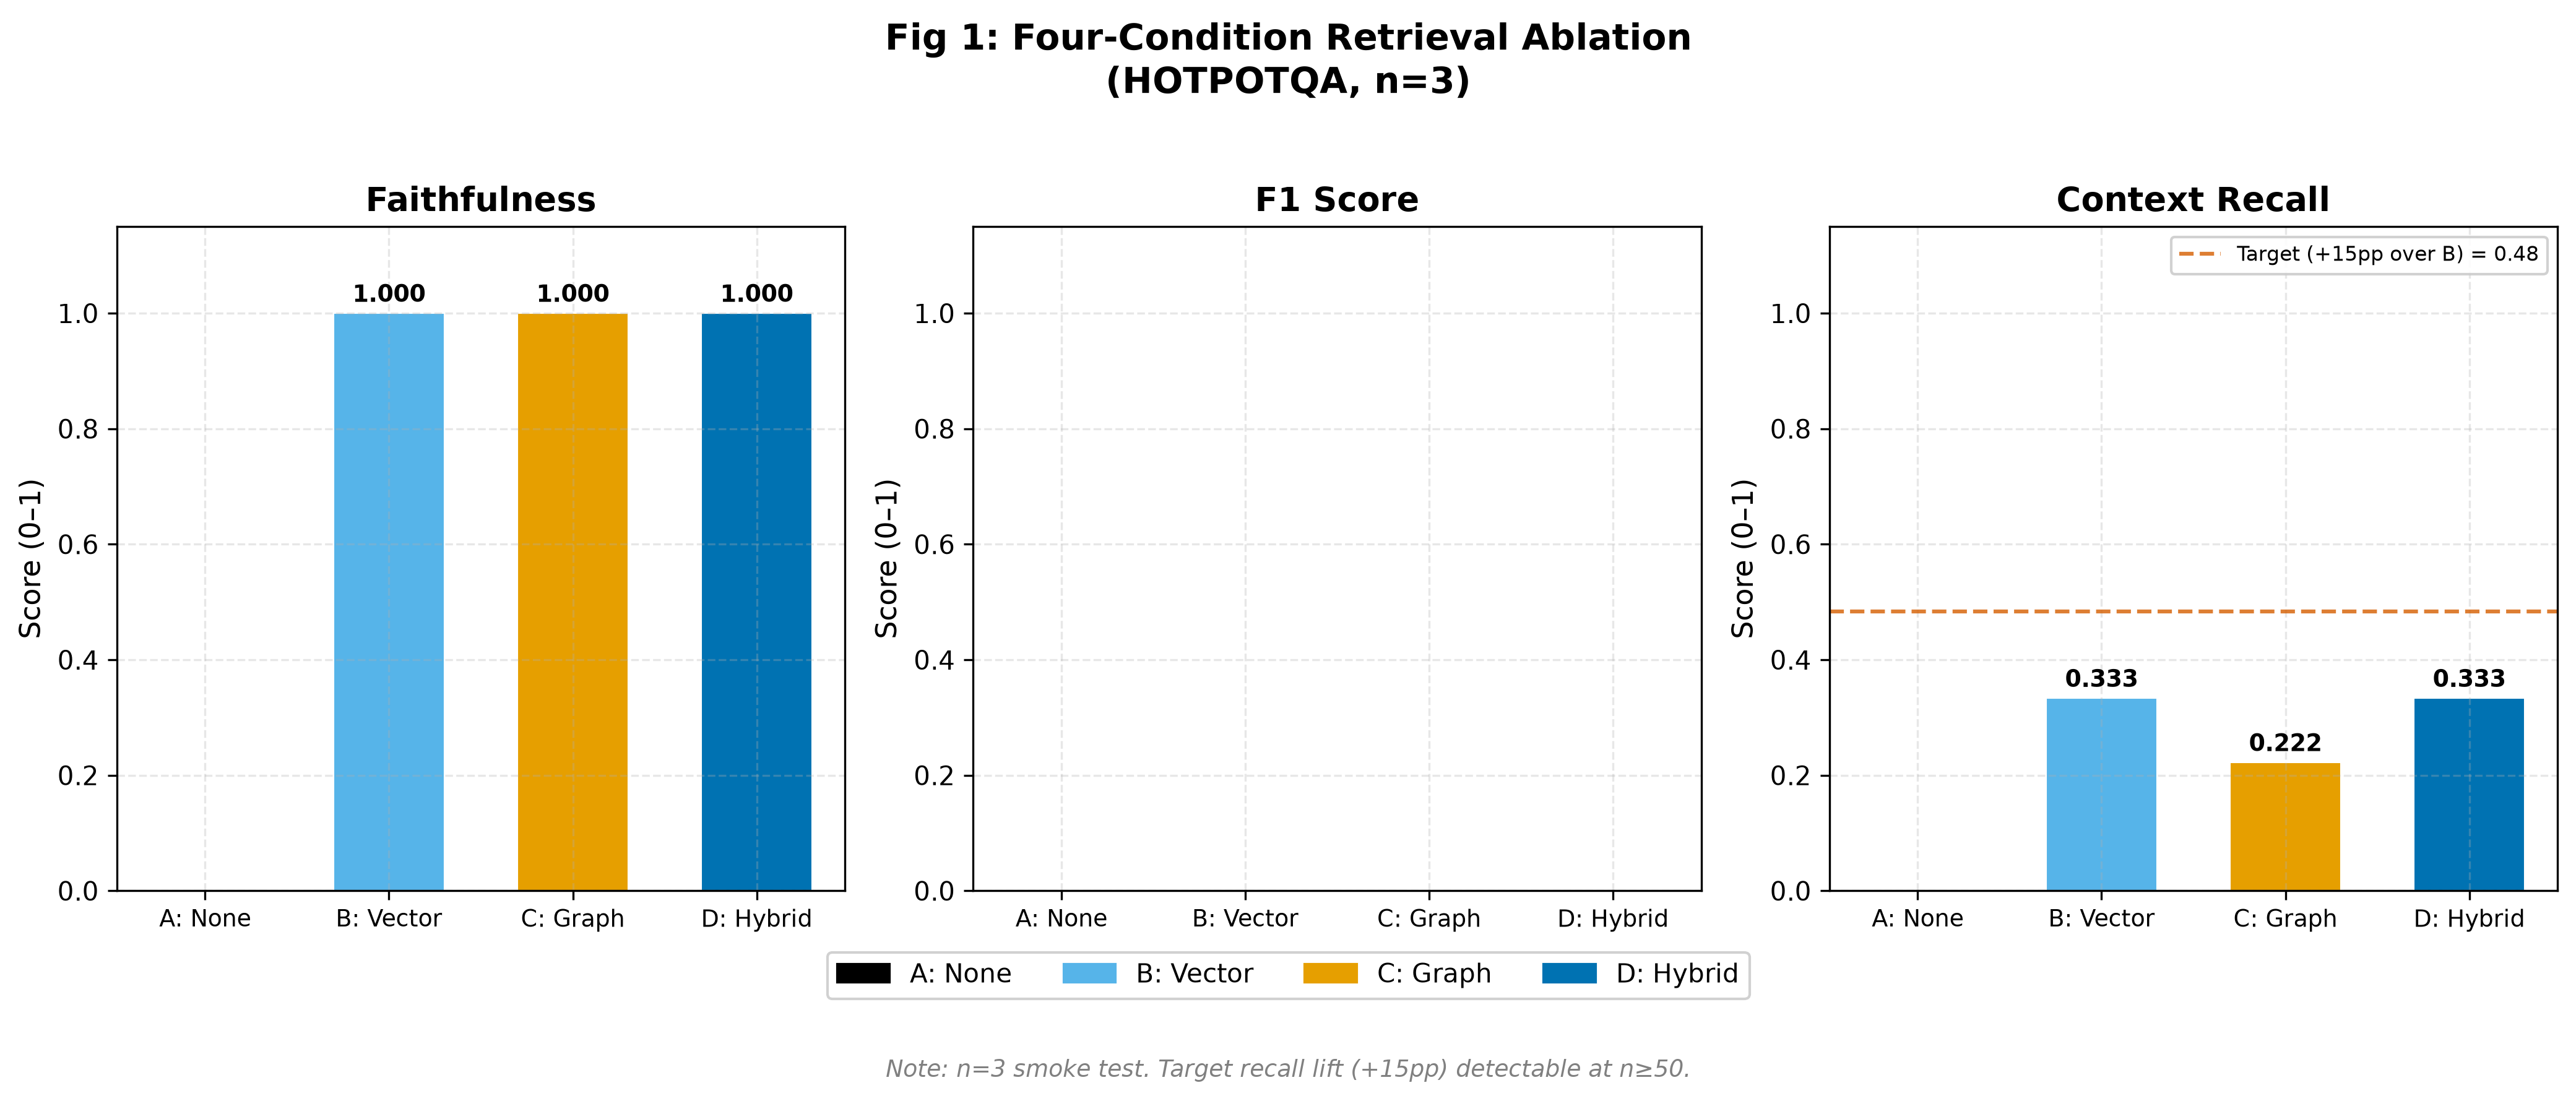


───────────────────────────────────────────────────────
Fig 2: Retry gate — no-gate vs with-gate paired comparison  (180 KB)


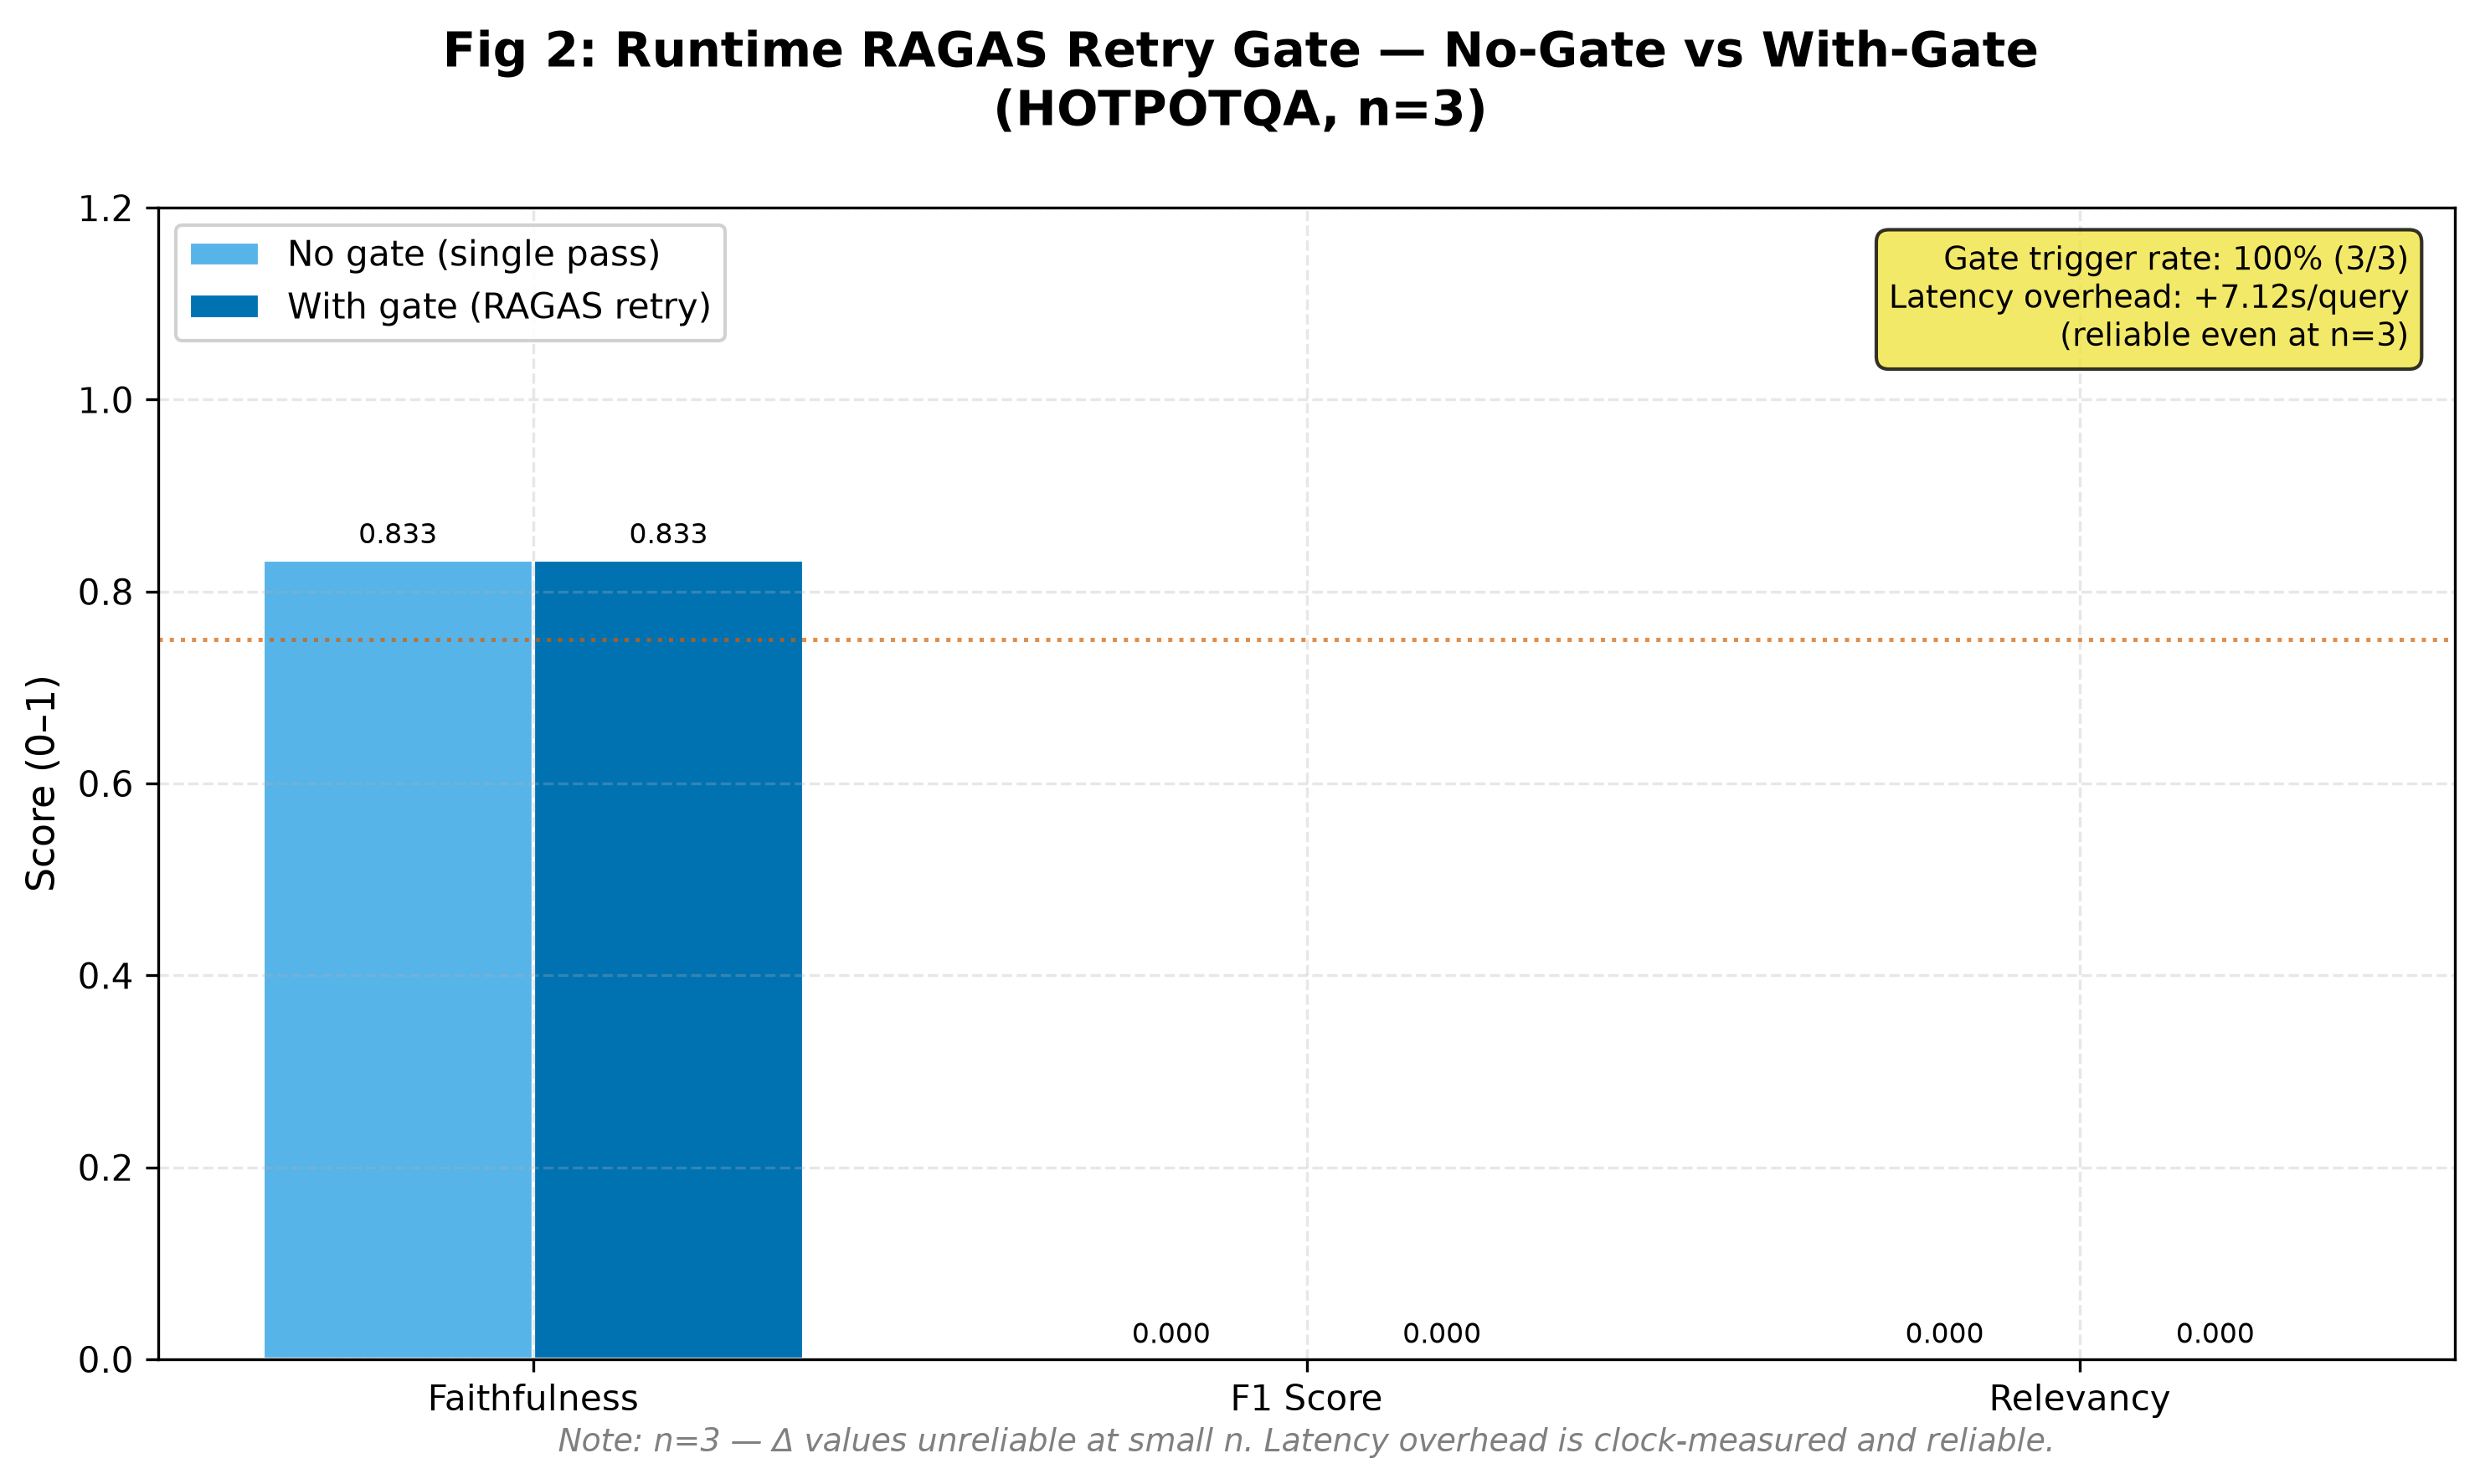


───────────────────────────────────────────────────────
Fig 3: CI/CD gate — V1 vs V2 threshold comparison  (144 KB)


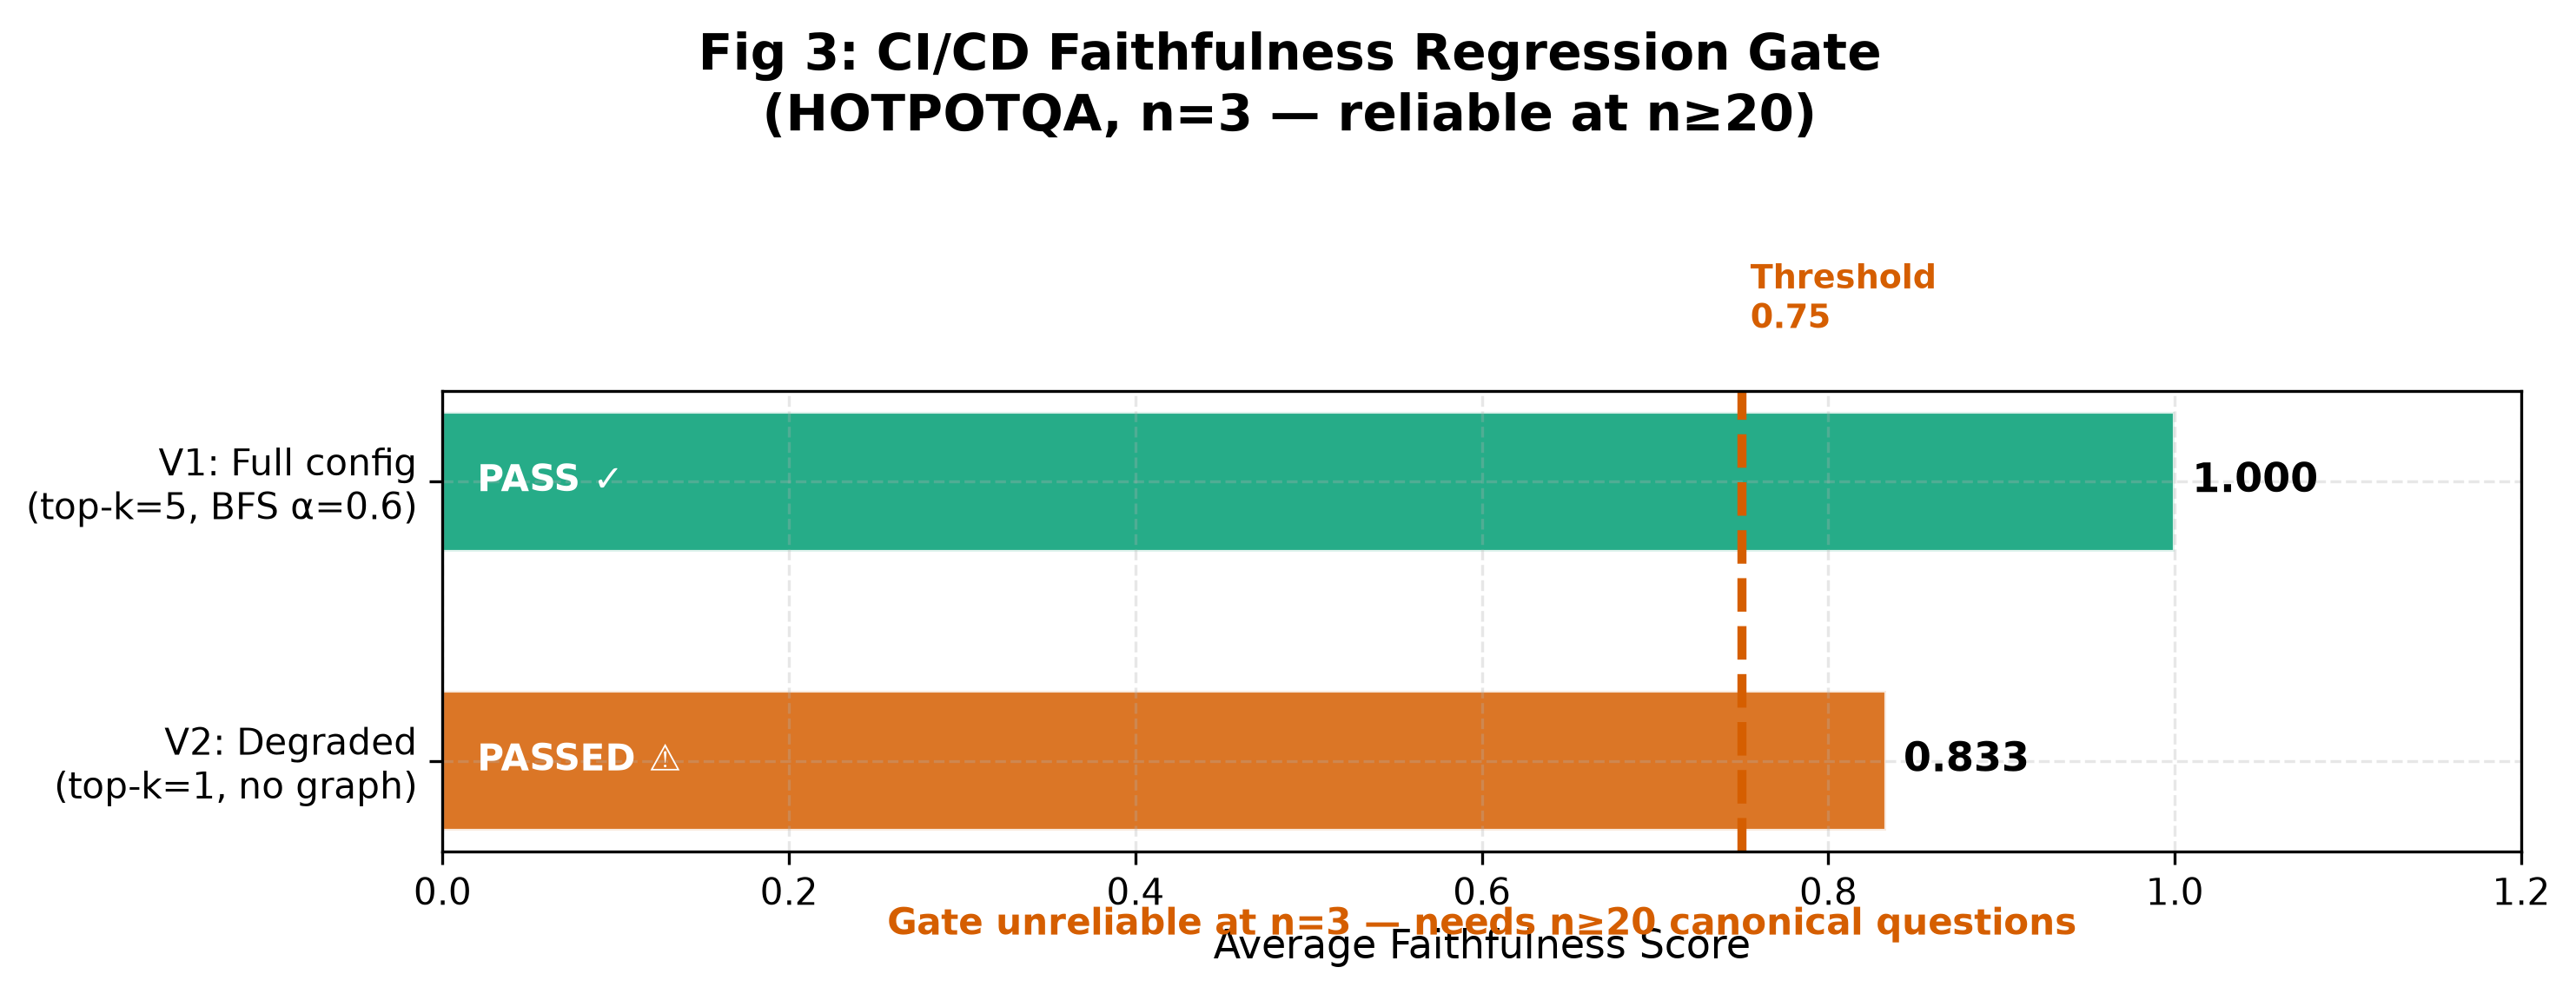


───────────────────────────────────────────────────────
Fig 4: Literature — positioning on capability vs F1 axes  (255 KB)


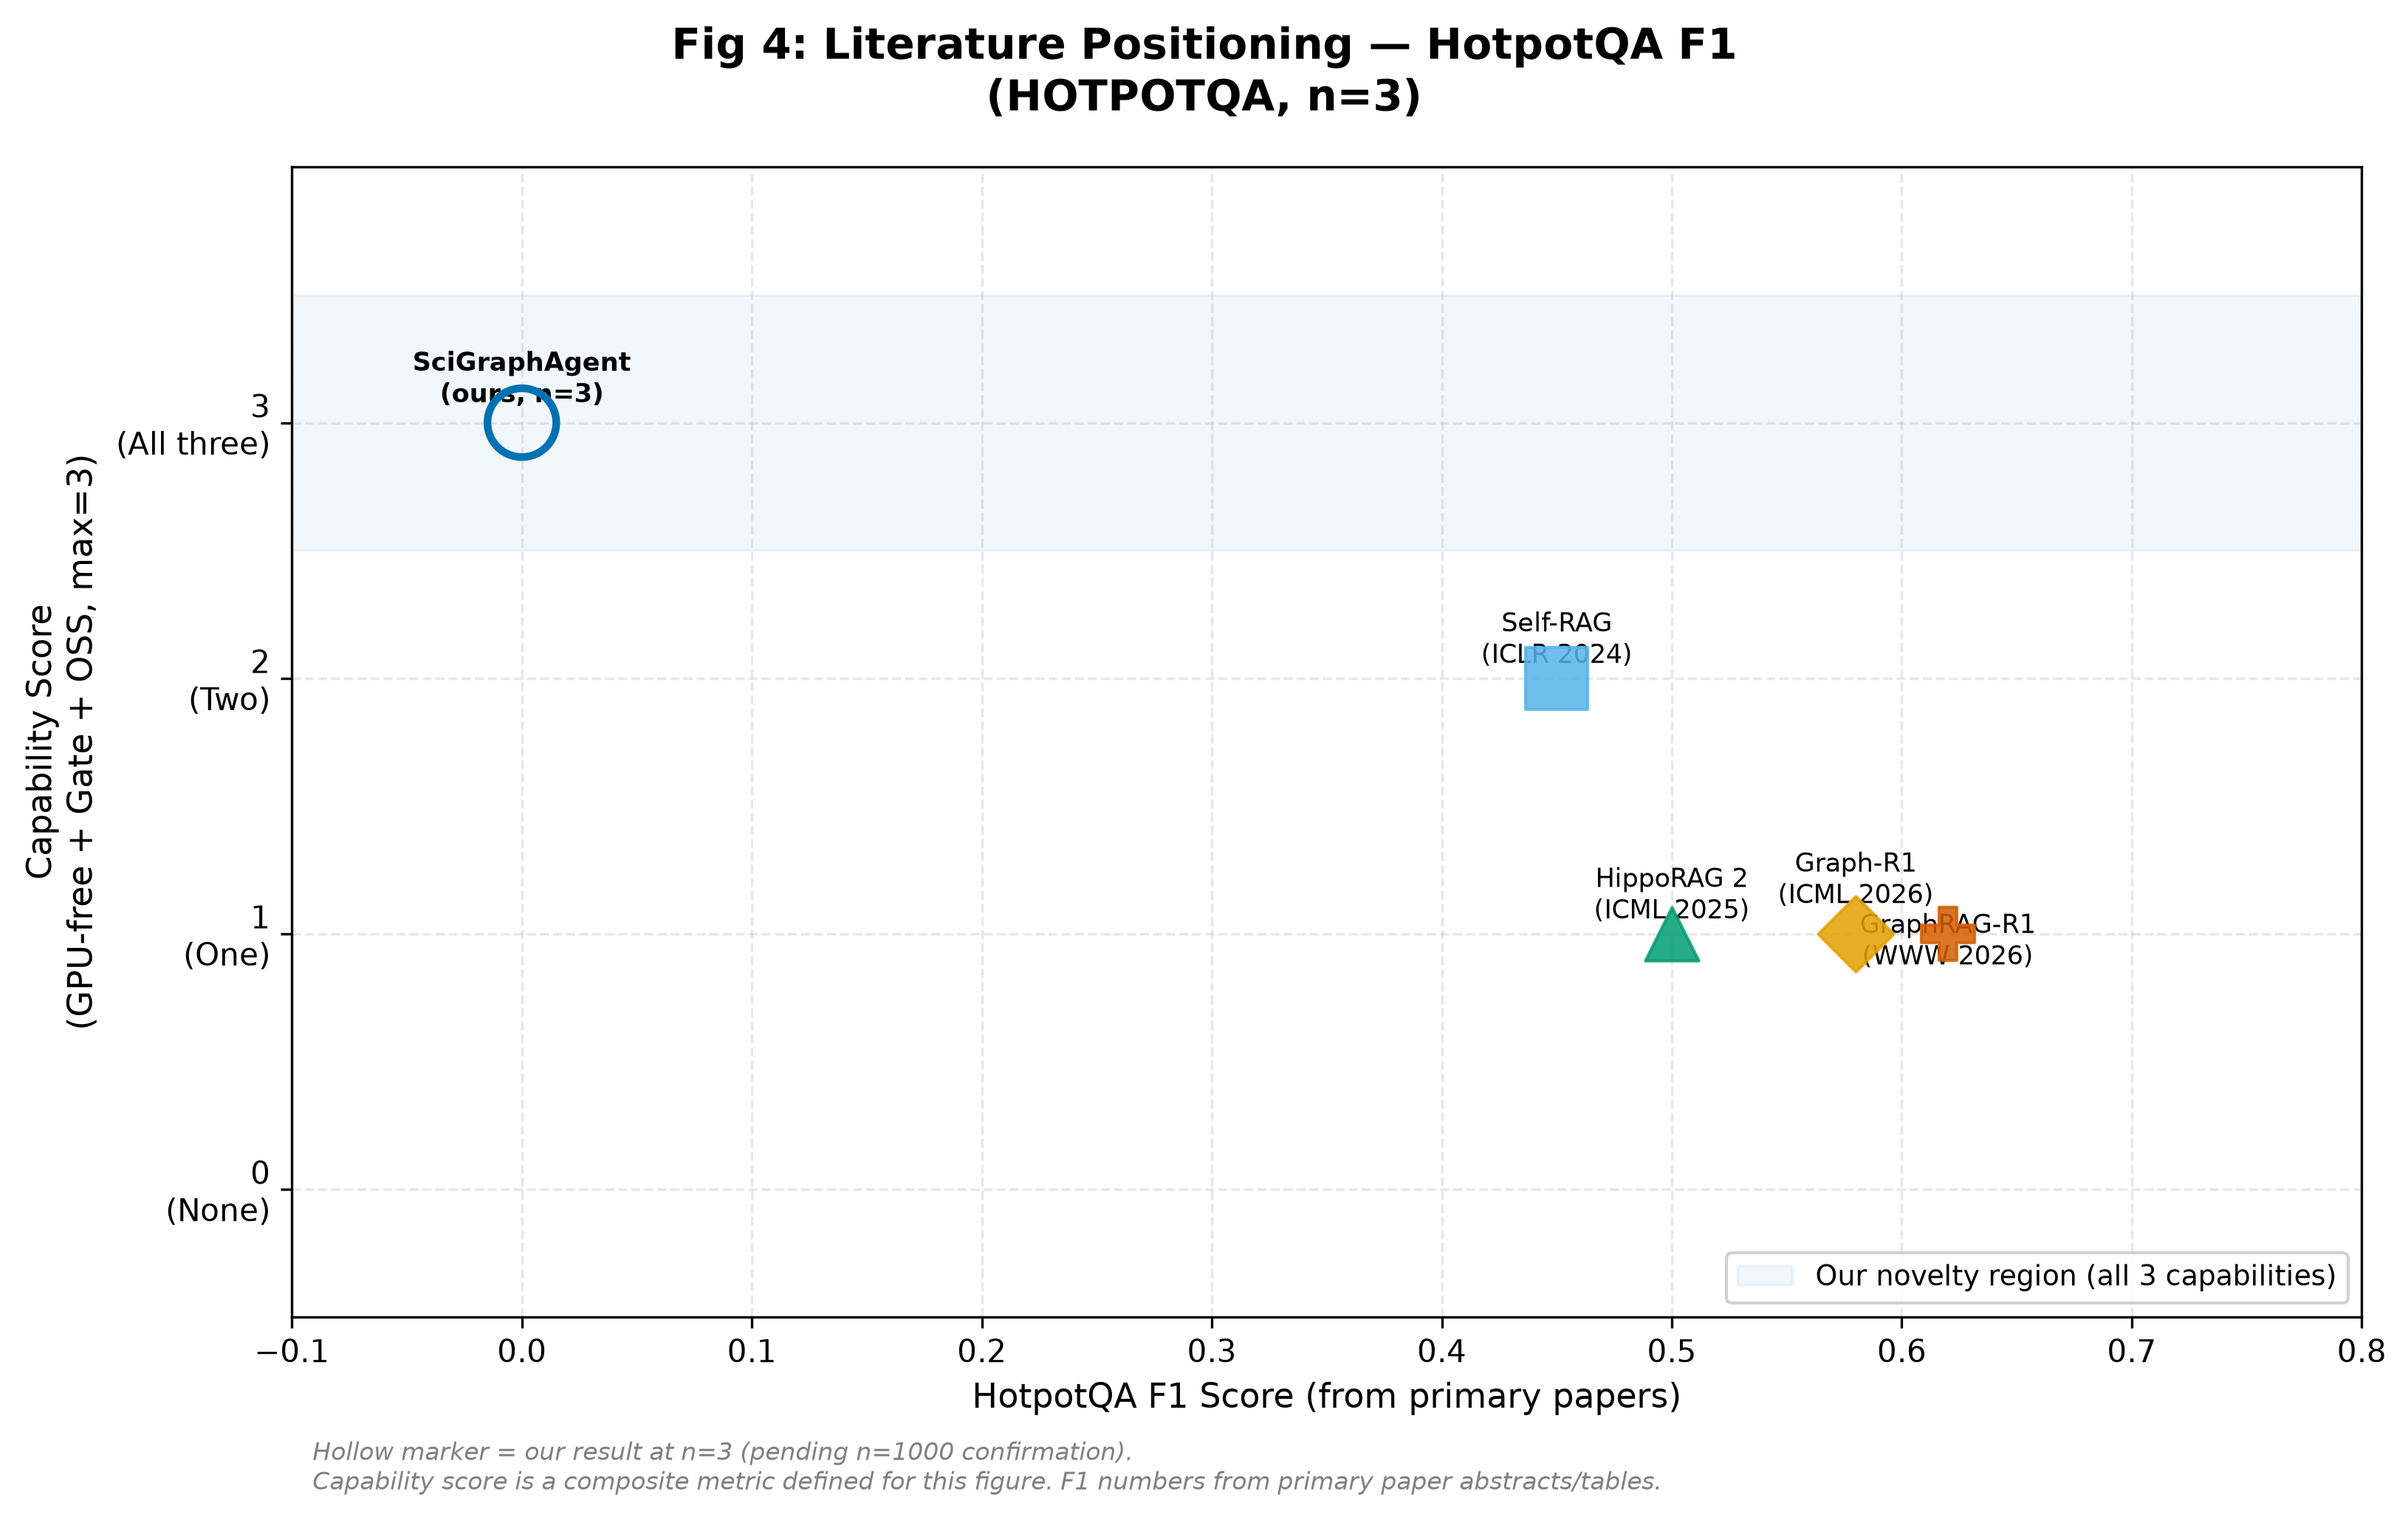


───────────────────────────────────────────────────────
Fig 5: Heatmap — per-question faithfulness patterns  (210 KB)


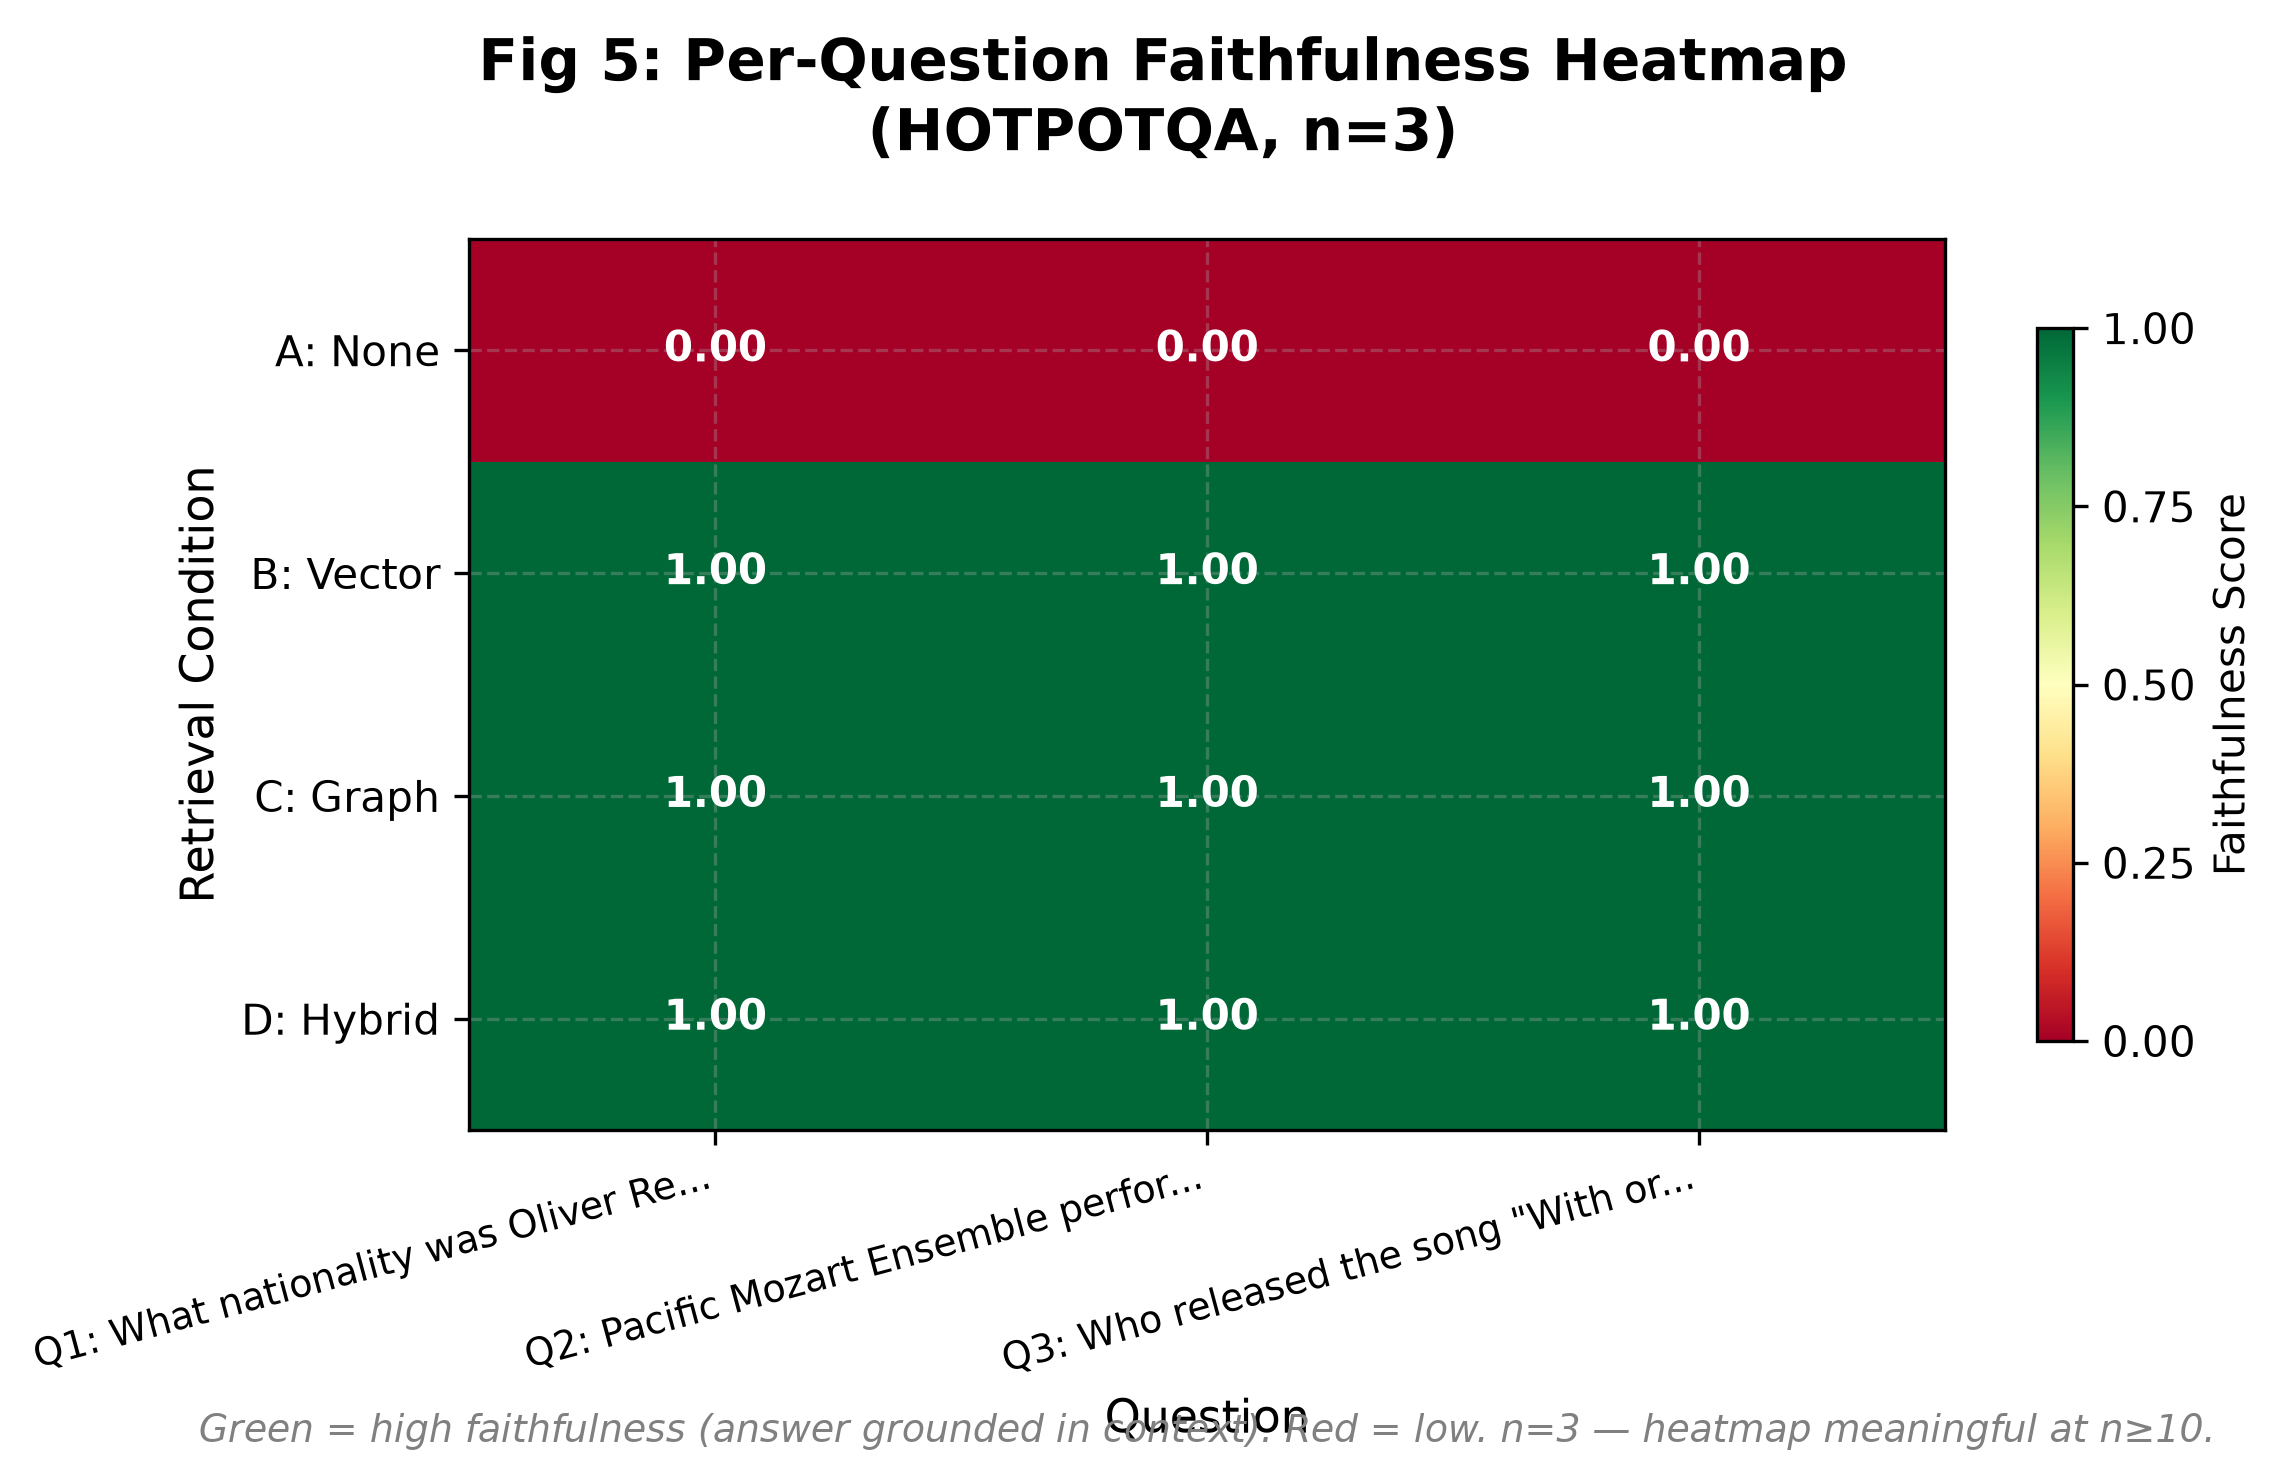

In [6]:
# Display all five figures inline in the notebook
# for quick review without opening external viewer

from IPython.display import display, Image
from pathlib import Path

figures_dir = Path("results") / "figures"
figure_files = sorted([
    f for f in figures_dir.glob("fig*_hotpotqa_3.png")
    if not f.name.startswith("_")
])

print(f"Displaying {len(figure_files)} figures inline:")
print()

descriptions = [
    "Fig 1: Ablation — compare A/B/C/D across faithfulness, F1, recall",
    "Fig 2: Retry gate — no-gate vs with-gate paired comparison",
    "Fig 3: CI/CD gate — V1 vs V2 threshold comparison",
    "Fig 4: Literature — positioning on capability vs F1 axes",
    "Fig 5: Heatmap — per-question faithfulness patterns",
]

for fig_path, desc in zip(figure_files, descriptions):
    size_kb = fig_path.stat().st_size // 1024
    print(f"─" * 55)
    print(f"{desc}  ({size_kb} KB)")
    display(Image(filename=str(fig_path), width=700))
    print()

---
## Section 9 — Applying the Two Cosmetic Fixes

After visual inspection, two cosmetic issues were identified:

**Fix 1 — Fig 4:** Graph-R1 and GraphRAG-R1 labels overlap at the bottom-right of the scatter plot. Both systems have similar F1 scores (~0.58 and ~0.62) and capability=1, causing their annotation labels to collide.

**Fix 2 — Fig 5:** Question labels at the bottom of the heatmap overlap with the note text. The x-axis labels are rotated 15° and the note text beneath them collide.

Both are layout/cosmetic issues — the data and arguments are correct. Apply the fixes in `step05_visualise.py` and regenerate.

In [7]:
# Verify the fixes were applied by checking the updated figures
# After making the two fixes in step05_visualise.py and re-running:
#   python step05_visualise.py --dataset hotpotqa --n 3
# Then re-run this cell to confirm the updates

import subprocess
from pathlib import Path

print("To apply the two fixes:")
print()
print("Fix 1 — Fig 4 (overlapping labels):")
print("  In fig4_literature(), find the annotation loop.")
print("  Replace:")
print('    offset_y = 0.08 if "ours" in name else 0.06')
print("  With:")
print('    offsets = {"Graph-R1": 0.12, "GraphRAG-R1": -0.12}')
print('    offset_y = 0.08 if "ours" in name else offsets.get(name.split("\\n")[0], 0.06)')
print()
print("Fix 2 — Fig 5 (heatmap bottom margin):")
print("  In fig5_heatmap(), change:")
print('    ax.text(0.5, -0.22, note, ...   → ax.text(0.5, -0.35, note, ...')
print("  Add before plt.tight_layout():")
print("    plt.subplots_adjust(bottom=0.3)")
print()
print("After making fixes, run in terminal:")
print("  python step05_visualise.py --dataset hotpotqa --n 3")
print("Then re-run Section 8 (display figures) to verify.")
print()

# Check current figure files
figs = sorted(Path("results/figures").glob("fig*_hotpotqa_3.png"))
print(f"Current figures ({len(figs)}):")
for f in figs:
    import time as _t
    mtime = _t.strftime('%H:%M:%S', _t.localtime(f.stat().st_mtime))
    print(f"  {f.name:<45} {f.stat().st_size//1024:>5} KB  modified {mtime}")

To apply the two fixes:

Fix 1 — Fig 4 (overlapping labels):
  In fig4_literature(), find the annotation loop.
  Replace:
    offset_y = 0.08 if "ours" in name else 0.06
  With:
    offsets = {"Graph-R1": 0.12, "GraphRAG-R1": -0.12}
    offset_y = 0.08 if "ours" in name else offsets.get(name.split("\n")[0], 0.06)

Fix 2 — Fig 5 (heatmap bottom margin):
  In fig5_heatmap(), change:
    ax.text(0.5, -0.22, note, ...   → ax.text(0.5, -0.35, note, ...
  Add before plt.tight_layout():
    plt.subplots_adjust(bottom=0.3)

After making fixes, run in terminal:
  python step05_visualise.py --dataset hotpotqa --n 3
Then re-run Section 8 (display figures) to verify.

Current figures (5):
  fig1_ablation_hotpotqa_3.png                    220 KB  modified 00:33:35
  fig2_retry_gate_hotpotqa_3.png                  180 KB  modified 00:33:36
  fig3_cicd_gate_hotpotqa_3.png                   144 KB  modified 00:33:36
  fig4_literature_hotpotqa_3.png                  255 KB  modified 00:33:37
  fig5_hea

---
## Section 10 — Pre-Commit Verification and Commit

In [8]:
import json, subprocess
from pathlib import Path

print("=" * 55)
print("PRE-COMMIT VERIFICATION")
print("=" * 55)

checks = []
def check(desc, ok, detail=""):
    checks.append(ok)
    print(f"  {'✓' if ok else '✗'}  {desc}")
    if detail: print(f"       {detail}")

# Script
check("step05_visualise.py exists",
      Path("step05_visualise.py").exists())

# Figures directory
figs_dir = Path("results") / "figures"
check("results/figures/ exists", figs_dir.exists())

# All five figures
expected_figs = [
    "fig1_ablation_hotpotqa_3.png",
    "fig2_retry_gate_hotpotqa_3.png",
    "fig3_cicd_gate_hotpotqa_3.png",
    "fig4_literature_hotpotqa_3.png",
    "fig5_heatmap_hotpotqa_3.png",
]
for fname in expected_figs:
    p = figs_dir / fname
    if p.exists():
        size_kb = p.stat().st_size // 1024
        check(f"{fname}", True, f"{size_kb} KB")
    else:
        check(f"{fname}", False, "missing — run step05")

# Verify figures are non-trivially sized (>50 KB means real content)
if figs_dir.exists():
    all_real = all(
        (figs_dir / f).stat().st_size > 50_000
        for f in expected_figs
        if (figs_dir / f).exists()
    )
    check("All figures have real content (>50 KB)", all_real)

# Input files
check("metrics_hotpotqa_3.json exists",
      (Path("results") / "metrics_hotpotqa_3.json").exists())

# Git status
print()
print("Git status:")
result = subprocess.run("git status --short", shell=True,
                        capture_output=True, text=True)
for line in result.stdout.strip().split("\n"):
    if line.strip(): print(f"  {line}")

passed = sum(checks)
total  = len(checks)
print()
print(f"{'✓' if passed == total else '✗'} {passed}/{total} checks passed")
print()
print("Note: results/figures/*.png are gitignored (large binary files).")
print("Only step05_visualise.py and the notebook are committed.")
print("Figures are regenerated from metrics JSON at any time.")
print()
print("Commit command:")
print("  git add step05_visualise.py notebooks/05_visualise.ipynb")
print('  git commit -m "Add step05 and Notebook 05: publication-quality figures"')
print("  git push")

PRE-COMMIT VERIFICATION
  ✓  step05_visualise.py exists
  ✓  results/figures/ exists
  ✓  fig1_ablation_hotpotqa_3.png
       220 KB
  ✓  fig2_retry_gate_hotpotqa_3.png
       180 KB
  ✓  fig3_cicd_gate_hotpotqa_3.png
       144 KB
  ✓  fig4_literature_hotpotqa_3.png
       255 KB
  ✓  fig5_heatmap_hotpotqa_3.png
       210 KB
  ✓  All figures have real content (>50 KB)
  ✓  metrics_hotpotqa_3.json exists

Git status:
  ?? 05_visualise.ipynb
  ?? step05_visualise.py

✓ 9/9 checks passed

Note: results/figures/*.png are gitignored (large binary files).
Only step05_visualise.py and the notebook are committed.
Figures are regenerated from metrics JSON at any time.

Commit command:
  git add step05_visualise.py notebooks/05_visualise.ipynb
  git commit -m "Add step05 and Notebook 05: publication-quality figures"
  git push


---
## Summary — What We Learned and How to Apply It

### Engineering constraints (Part A)

| Concept | Rule | Generalise |
|---|---|---|
| Step cost | step05 = $0, zero API calls | Separate figure generation from data collection |
| Matplotlib backend | `use('Agg')` for headless environments | Any script-generated figures on servers/CI |
| 300 dpi | Required for IEEE/ACM/NeurIPS/ICML | All academic paper figures |
| `bbox_inches='tight'` | Prevents label clipping | Every savefig call |
| Colour-blind palette | Wong (2011) 8-colour set | All published or printed figures |
| Colour consistency | Same category = same colour across all figures | Any multi-figure document |

### Visualisation concepts (Part B)

| Figure type | Use when | Applied to |
|---|---|---|
| Grouped bar | N categories × M metrics | Ablation across conditions |
| Paired bar | Treatment vs control | Gate vs no-gate comparison |
| Horizontal gauge | Value vs threshold | CI/CD pass/fail verdict |
| Scatter plot | Two-axis positioning | Literature novelty positioning |
| Heatmap | 2D pattern matrix | Per-question faithfulness |

### Honesty rules for figures

1. Start bar charts at y=0 — never truncate the axis
2. Include sample size in the title — `(n=3)` signals reliability level
3. Add italic notes for limitations — visible without reading the text
4. Use hollow markers for unconfirmed results — signals "pending"
5. Show uncertainty — error bars at n≥10, SE annotations at n≥30

### Engineering decisions in step05 — with reasoning

| Decision | Choice | Alternative | Reason |
|---|---|---|---|
| Library | matplotlib | Plotly, seaborn | 300 dpi PNG without extra deps |
| Backend | Agg | TkAgg, Qt5Agg | Works headless — servers, CI/CD |
| Resolution | 300 dpi | 150 or 72 | IEEE/ACM minimum requirement |
| Palette | Wong 2011 | matplotlib defaults | Colour-blind accessible |
| Target line | B+0.15 on recall | fixed 0.48 | Shows the claim relative to baseline |
| Hollow marker | Our system at n=3 | filled marker | Signals unconfirmed result honestly |
| Figures directory | results/figures/ | project root | Gitignored — binary files not in repo |

### What is gitignored and why

The PNG files in `results/figures/` are **gitignored** — they are large binary files that change every time step05 runs (even with identical data, minor rendering differences create different bytes). Instead, we commit:
- `step05_visualise.py` — the code that generates them
- `results/metrics_{dataset}_{n}.json` — the data they are generated from (gitignored too)

Anyone who clones the repo can regenerate all five figures in under 5 seconds by running `python step05_visualise.py`. This is better than storing large binary files in the repo.

### What comes next — Step06

Step06 builds an interactive Streamlit dashboard that reads the same metrics JSON and displays all results with interactive Plotly charts. Users can adjust thresholds, switch datasets, and drill into per-question results.

Unlike step05 (static PNG), step06 produces a live web application.

---
*Notebook 05 complete. Move to `notebooks/`, run all cells, commit both files together.*